In [28]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [9]:
# Load the Online Retail dataset

df = pd.read_excel('/content/Online Retail.xlsx')

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

Dataset loaded successfully.
Shape of dataset: (541909, 8)


In [10]:
# Inspect the dataset structure

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [11]:
# Data Cleaning
# Remove missing customer IDs and descriptions
# Remove duplicate transactions and cancelled/return transactions

print("Rows before cleaning:", len(df))

# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows without Description
df = df.dropna(subset=['Description'])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Rows after cleaning:", len(df))
print("Missing CustomerID:", df['CustomerID'].isnull().sum())
print("Missing Description:", df['Description'].isnull().sum())

Rows before cleaning: 541909
Rows after cleaning: 392692
Missing CustomerID: 0
Missing Description: 0


In [12]:
# Create total purchase value

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Customer-level descriptive statistics

customer_stats = df.groupby('CustomerID').agg(
    Average_Purchase_Value=('TotalAmount', 'mean'),
    Purchase_Frequency=('InvoiceNo', 'nunique'),
    Customer_Lifetime_Value=('TotalAmount', 'sum')
)

print("Customer-level statistics:")
display(customer_stats.describe())

Customer-level statistics:


,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
count,4338.000000,4338.000000,4338.000000
mean,68.381590,4.272015,2048.688081
std,1467.918294,7.697998,8985.230220
min,2.136970,1.000000,3.750000
25%,12.393196,1.000000,306.482500
50%,17.755000,2.000000,668.570000
75%,24.878950,5.000000,1660.597500
max,77183.600000,209.000000,280206.020000


In [13]:
# RFM Analysis

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

print("RFM dataset shape:", rfm.shape)

display(rfm.head())

print("RFM descriptive statistics:")
display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM dataset shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


RFM descriptive statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [14]:
# Feature Selection and Standardisation

from sklearn.preprocessing import StandardScaler

# Select key behavioural features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardise the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Selected features:", list(rfm_features.columns))
print("Standardised RFM data shape:", rfm_scaled.shape)

Selected features: ['Recency', 'Frequency', 'Monetary']
Standardised RFM data shape: (4338, 3)


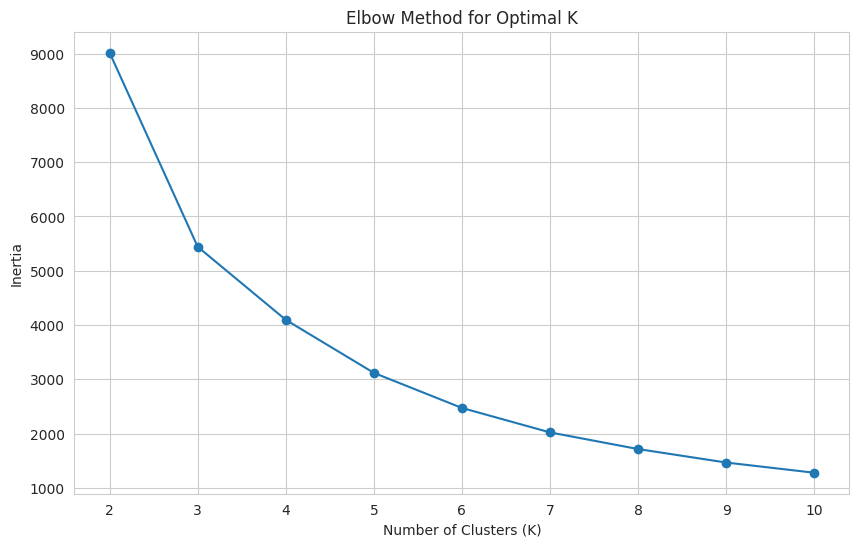

In [15]:
# Elbow Method to Determine Optimal Number of Clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# Test different numbers of clusters
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [16]:
### Elbow Method - Observation

### The Elbow Method was used to determine the appropriate number of customer clusters.

### The inertia decreases as the number of clusters increases, with the elbow indicating that 4 clusters provide a suitable balance between model simplicity and customer segmentation quality.

### Therefore, K = 4 was selected for the K-Means clustering analysis.

In [17]:
# K-Means Clustering

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed.")
print("Number of clusters:", optimal_k)
print("\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering completed.
Number of clusters: 4

Customers per cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [18]:
# Cluster Profiling

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("Average RFM values by cluster:")
display(cluster_profile)

print("\nCluster sizes:")
display(rfm['Cluster'].value_counts().sort_index().rename('Customer_Count'))

Average RFM values by cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50



Cluster sizes:


,Customer_Count
Cluster,
0,3054
1,1067
2,13
3,204


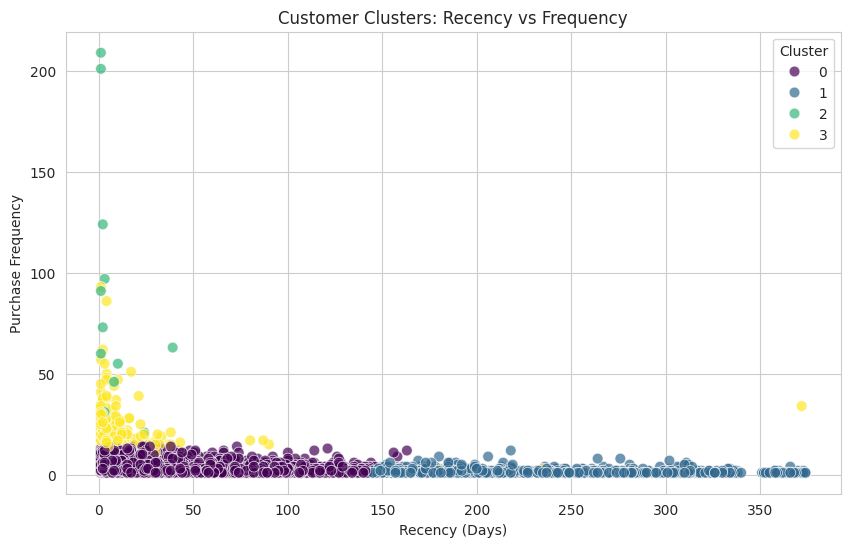

In [19]:
# Cluster Visualization - Recency vs Frequency

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=60,
    alpha=0.7
)

plt.title('Customer Clusters: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Cluster')
plt.show()


In [20]:
### Recency vs Frequency - Observation

### The scatter plot shows clear differences in customer purchasing behaviour across the four clusters.

### Cluster 1 contains customers with high recency and low purchase frequency, indicating inactive or at-risk customers.

### Clusters 2 and 3 show more recent purchasing behaviour with substantially higher frequency, representing highly engaged and valuable customers.

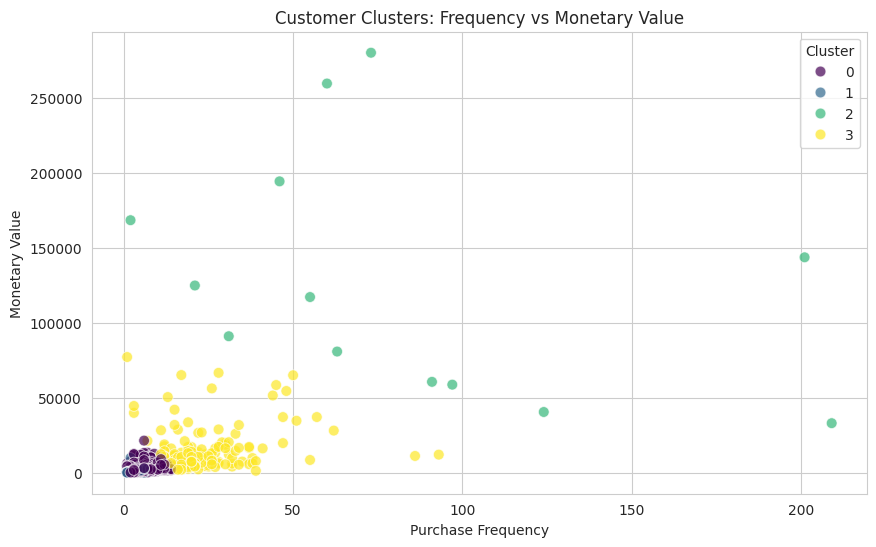

In [21]:
# Cluster Visualization - Frequency vs Monetary

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60,
    alpha=0.7
)

plt.title('Customer Clusters: Frequency vs Monetary Value')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

In [22]:
### Frequency vs Monetary Value - Observation

### The scatter plot shows that customers with higher purchase frequency generally contribute higher monetary value.

### Cluster 2 represents a very small group of exceptionally high-value customers, while Cluster 3 represents high-value loyal customers.

### Clusters 0 and 1 contain customers with comparatively lower purchasing frequency and monetary contribution.

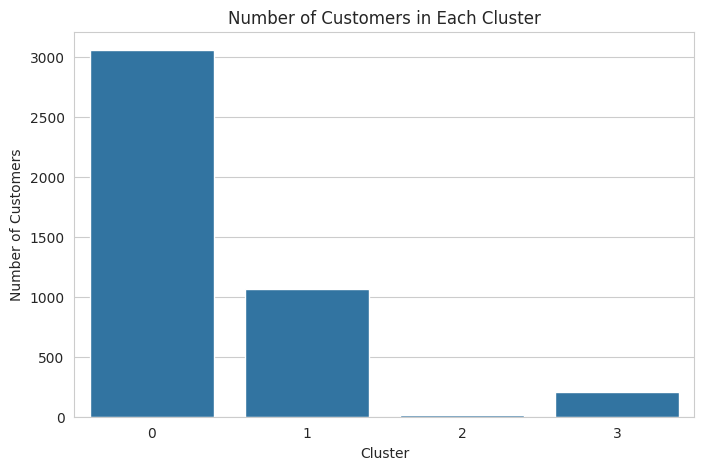

Customers per cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [23]:
# Customer count in each cluster

cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

print("Customers per cluster:")
print(cluster_counts)

In [24]:
### Customer Count by Cluster - Observation

### Cluster 0 is the largest segment with 3,054 customers, followed by Cluster 1 with 1,067 customers.

### Cluster 3 contains 204 customers, while Cluster 2 contains only 13 customers.

### Although Cluster 2 is the smallest segment, its extremely high monetary value makes it strategically important for VIP retention and personalized marketing.

In [25]:
# Cluster profiling

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("Cluster Profile:")
display(cluster_profile)

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [26]:
### Cluster Profile - Observation

### Cluster 0 represents regular customers with moderate recency, frequency and monetary value.

### Cluster 1 represents inactive customers because they have high recency and relatively low frequency and monetary value.

### Cluster 2 represents VIP customers with extremely recent purchases, very high frequency and exceptionally high monetary value.

### Cluster 3 represents high-value loyal customers with recent purchases, high frequency and high monetary value.

In [27]:
print("Customer Segmentation Insights:\n")

print("Cluster 0 - Regular Customers:")
print("Moderate recency, frequency and monetary value.")
print("Marketing action: Use personalized offers and loyalty rewards to increase purchase frequency and spending.\n")

print("Cluster 1 - Inactive Customers:")
print("High recency with low frequency and low monetary value.")
print("Marketing action: Use re-engagement campaigns, discounts and reminder emails to encourage repeat purchases.\n")

print("Cluster 2 - VIP Customers:")
print("Very recent purchases, extremely high frequency and very high monetary value.")
print("Marketing action: Provide VIP benefits, exclusive products and personalized service to retain these highly valuable customers.\n")

print("Cluster 3 - High-Value Loyal Customers:")
print("Recent purchases with high purchase frequency and high monetary value.")
print("Marketing action: Strengthen loyalty through rewards, premium offers and cross-selling opportunities.")

Customer Segmentation Insights:

Cluster 0 - Regular Customers:
Moderate recency, frequency and monetary value.
Marketing action: Use personalized offers and loyalty rewards to increase purchase frequency and spending.

Cluster 1 - Inactive Customers:
High recency with low frequency and low monetary value.
Marketing action: Use re-engagement campaigns, discounts and reminder emails to encourage repeat purchases.

Cluster 2 - VIP Customers:
Very recent purchases, extremely high frequency and very high monetary value.
Marketing action: Provide VIP benefits, exclusive products and personalized service to retain these highly valuable customers.

Cluster 3 - High-Value Loyal Customers:
Recent purchases with high purchase frequency and high monetary value.
Marketing action: Strengthen loyalty through rewards, premium offers and cross-selling opportunities.
